<a href="https://colab.research.google.com/github/woalsse/KOSPI-VaR-Backtesting-Project/blob/main/codes/1_log_return_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q yfinance --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 7.3 MB/s eta 0:00:00


Ticker      : ^KS11
Period      : 2015-01-05 ~ 2026-07-30
Observations: 2,836

Descriptive Statistics
  Mean (daily)    : 0.000376
  Std dev (daily) : 0.013757
  Annualized vol  : 0.2184
  Skewness        : -0.9282
  Excess kurtosis : 13.7095
  Minimum         : -0.1285 (2026-03-04)
  Maximum         : 0.0919 (2026-03-05)

Jarque-Bera Normality Test
  Statistic : 22531.33
  p-value   : 0
  Result    : Reject H0 at 5% level

Worst daily return         : -9.37 sigma
Probability under normality: 3.711e-21


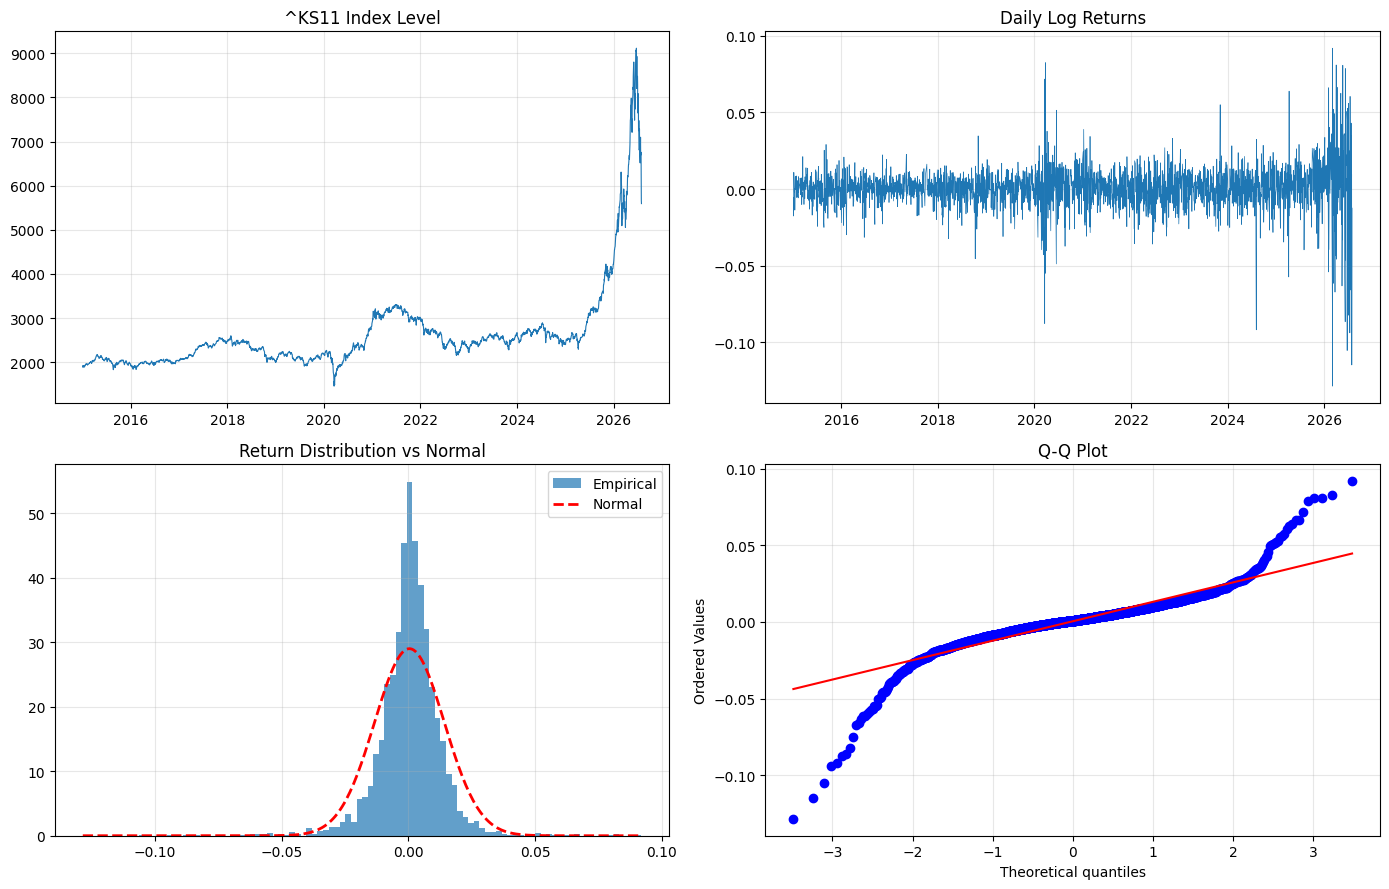

In [1]:
"""KOSPI 일별 로그수익률의 기초통계량 및 정규성 진단."""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf


TICKER = "^KS11"
START_DATE = "2015-01-01"
END_DATE = "2026-07-31"
TRADING_DAYS = 252

FIGURE_DIR = "figures"
DATA_DIR = "data"


def load_prices(ticker, start, end):
    """Yahoo Finance에서 수정종가를 받아온다.

    KRX 정보데이터시스템이 회원제로 전환되면서 pykrx는 로그인 정보를
    요구하게 되어, 인증이 필요 없는 Yahoo Finance로 대체했다.
    """
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)

    if raw is None or len(raw) == 0:
        raise SystemExit(f"데이터 수집 실패: {ticker}")

    # 최근 버전의 yfinance는 단일 티커 요청에도 2단 컬럼을 반환하므로
    # 1단으로 평탄화한다.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    return pd.DataFrame({"close": raw["Close"]}).dropna()


def compute_log_returns(prices):
    """로그수익률을 계산한다. 보유기간 간 가법성 때문에 단순수익률 대신 사용."""
    df = prices.copy()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df.dropna()


def summarize(returns):
    print(f"Ticker      : {TICKER}")
    print(f"Period      : {returns.index[0].date()} ~ {returns.index[-1].date()}")
    print(f"Observations: {len(returns):,}")
    print()

    print("Descriptive Statistics")
    print(f"  Mean (daily)    : {returns.mean():.6f}")
    print(f"  Std dev (daily) : {returns.std():.6f}")
    print(f"  Annualized vol  : {returns.std() * np.sqrt(TRADING_DAYS):.4f}")
    print(f"  Skewness        : {returns.skew():.4f}")
    # pandas는 초과첨도를 반환한다. 정규분포 기준값은 3이 아니라 0.
    print(f"  Excess kurtosis : {returns.kurtosis():.4f}")
    print(f"  Minimum         : {returns.min():.4f} ({returns.idxmin().date()})")
    print(f"  Maximum         : {returns.max():.4f} ({returns.idxmax().date()})")
    print()

    jb_stat, jb_pvalue = stats.jarque_bera(returns)
    print("Jarque-Bera Normality Test")
    print(f"  Statistic : {jb_stat:.2f}")
    print(f"  p-value   : {jb_pvalue:.6g}")
    print(f"  Result    : {'Reject H0' if jb_pvalue < 0.05 else 'Fail to reject H0'} at 5% level")
    print()

    # 최대 손실일을 표준편차 단위로 환산해, 정규분포 가정 하에서
    # 해당 사건이 얼마나 비현실적인지를 수치로 보인다.
    z_min = (returns.min() - returns.mean()) / returns.std()
    print(f"Worst daily return         : {z_min:.2f} sigma")
    print(f"Probability under normality: {stats.norm.cdf(z_min):.3e}")


def plot_diagnostics(df, returns, path):
    # 그래프 라벨은 한글 폰트 문제를 피하기 위해 영문으로 유지한다.
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(df.index, df["close"], linewidth=0.8)
    axes[0, 0].set_title(f"{TICKER} Index Level")
    axes[0, 0].grid(alpha=0.3)

    # 변동성 군집이 있다면 안정 구간과 급변 구간이 교대로 나타난다.
    axes[0, 1].plot(df.index, returns, linewidth=0.5)
    axes[0, 1].set_title("Daily Log Returns")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(returns, bins=100, density=True, alpha=0.7, label="Empirical")
    x = np.linspace(returns.min(), returns.max(), 300)
    axes[1, 0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
                    "r--", linewidth=2, label="Normal")
    axes[1, 0].set_title("Return Distribution vs Normal")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    stats.probplot(returns, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


def main():
    os.makedirs(FIGURE_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)

    prices = load_prices(TICKER, START_DATE, END_DATE)
    df = compute_log_returns(prices)
    returns = df["log_return"]

    summarize(returns)
    plot_diagnostics(df, returns, os.path.join(FIGURE_DIR, "day1_returns_analysis.png"))

    # 2주차 VaR 계산에서 이 파일을 그대로 불러 쓴다.
    df.to_csv(os.path.join(DATA_DIR, "kospi_returns.csv"), encoding="utf-8-sig")


if __name__ == "__main__":
    main()